In [1]:
import pandas as pd
import numpy as np

# 범주형 데이터 변환 
from sklearn.preprocessing import LabelEncoder # 이후부터 용어 변화 존재 
le = LabelEncoder()

# 데이터 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 데이터 시각화 분석 라이브러리 
import matplotlib.pyplot as plt

import seaborn as sns

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# 데이터 형태 
df.shape

(244, 7)

In [5]:
# 데이터 타입
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [6]:
# 데이터 정보 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
# 데이터 결측치
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
239    False
240    False
241    False
242    False
243    False
Length: 244, dtype: bool

### 1. 범주형 데이터 구분 > 범주형 데이터 분석

In [9]:
df['sex'].unique()

['Female', 'Male']
Categories (2, object): ['Male', 'Female']

문제 정의 1 . 어떤 손님들이 왔는가 

In [10]:
df_male = df[df['sex'] == 'Male']
df_male.head()

print(f"방문한 남자 손님의 수는 {len(df_male)}명입니다.")

df_female = df[df['sex']=='Female']
df_female.head()

print(f"방문한 여자 손님의 수는 {len(df_female)}명입니다.")

방문한 남자 손님의 수는 157명입니다.
방문한 여자 손님의 수는 87명입니다.


In [11]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

2. 외식비용 총금액과 총금액의 관계 분석

1) Scatter plot

In [12]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

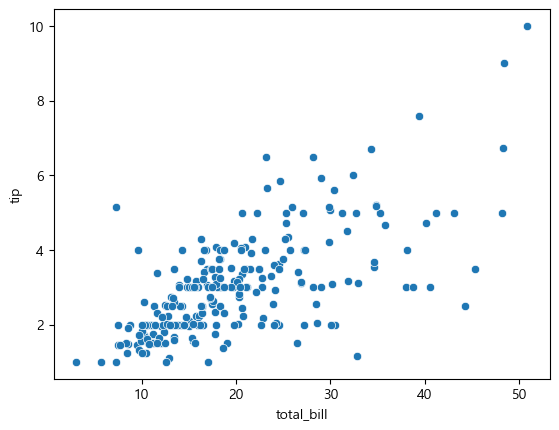

In [13]:
sns.scatterplot(data = df , x = 'total_bill' , y = 'tip')

<Figure size 400x300 with 0 Axes>

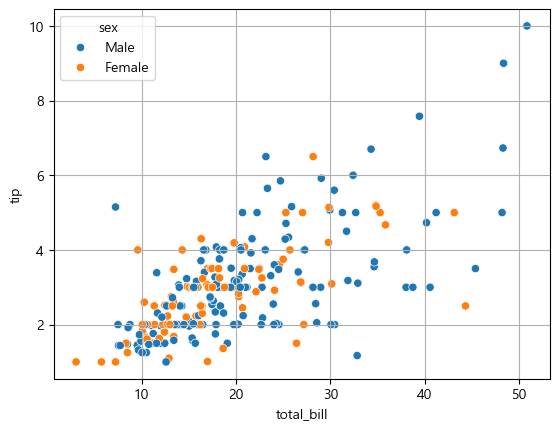

<Figure size 400x300 with 0 Axes>

In [14]:
sns.scatterplot(x = df['total_bill'] , y = df['tip'] , hue = df['sex']) # hue : 3차원 축 
plt.grid()
plt.figure(figsize = (4,3))  

# matplot 과 seaborn은 통상 함께 사용한다.


#### 인사이트 <데이터 기반>

- 총 지불 비용이 커짐에 따라 tip 발생 금액은 커짐 => 비례한다.
- 남성의 경우 , 50불 이상 식사 비용을 지불할때 , 10% 팁이 <통상팁>으로 간주할때 팁 비율이 평균 팁 비율(5)보다 상위에서 지불되는 경우가 존재함.
- 여성의 경우 , 10불 이하 지불시 통상 팁 비율보다 1불 이하의 팁으로 발생되는 경우가 존재함 .
- 남성의 경우 , 상대적으로 정상적인 팁 비율보다 상위하는 금액으로 팁이 발생하는 경우가 관찰됨.

<Figure size 400x300 with 0 Axes>

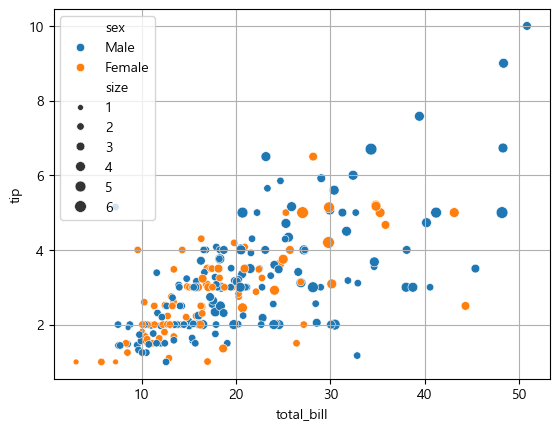

<Figure size 400x300 with 0 Axes>

In [15]:
sns.scatterplot(x = df['total_bill'] , y = df['tip'] , hue = df['sex'] , size = df['size']) # hue : 3차원 축 
# size : 4차원 축
plt.grid()
plt.figure(figsize = (4,3))  

# matplot 과 seaborn은 통상 함께 사용한다.

#### 인사이트 <데이터 기반>

3차원 (성별 [sex] )
- 총 지불 비용이 커짐에 따라 tip 발생 금액은 커짐 => 비례한다.
- 남성의 경우 , 50불 이상 식사 비용을 지불할때 , 10% 팁이 <통상팁>으로 간주할때 팁 비율이 평균 팁 비율(5)보다 상위에서 지불되는 경우가 존재함.
- 여성의 경우 , 10불 이하 지불시 통상 팁 비율보다 1불 이하의 팁으로 발생되는 경우가 존재함 .
- 남성의 경우 , 상대적으로 정상적인 팁 비율보다 상위하는 금액으로 팁이 발생하는 경우가 관찰됨.

4차원 (그룹의 사이즈 [size] )
- 

[전체 데이터 인사이트 분석]
- 식사 금액이 높을수록 팁도 증가하는 경향이 존재함. 
- 식사 총 금액이 10~20 달러인 경우는 주로 팁은 1~4달러 사이에 집중되어 있음
- 총 금액이 30달러 이상인 경우 팁이 4달러 이상으로 올라가는 경우가 존재함

[남성/여성 고객데이터]
- 파란색 점인 남성 데이터가 전체적으로 더 넓은 범위에 분포되어서 존재함
- 총 외식 비용이 30달러 이상이거나 팁이 6달러 이상인 고금액 구간에서는 남성 데이터가 상대적으로 많이 관찰된다.
- 여성 데이터는 중간 금액대에서 많이 분포하고 , 매우 높은 결제 금액과 팁 구간에서는 남성 데이터가 더 두드러지게 나타남

[특이값 분석]
- 오른쪽 상단 총 외식 비용이 약 50 달러 이상이고 , 팁이 10달러 정도인 데이터가 존재함.
- 매우 높은 결제 금액과 높은 팁이 발생한 특이치 데이터로 관찰이 필요함
- 그러나 , 결제 금액이 40 달러 이상인데 팁은 2~3 정도인 수준인 데이터가 존재함.

[인원사이즈 분석]
- 3인 이상의 단체 식사의 경우 주로 20달러 이상에서 형성되어 있음
- 1인 식사는 15달러 이하에서 관측되는데도 불구하고 3인 이상은 20~30달러 구간에서 데이터가 존재함
- 20달러 이상에서 여성의 경우 같은 사이즈임에도 팁의 발생 패턴이 상이함
- 상대적으로 식사 그룹중 큰 4명 이상의 경우 , 25달러 이상 구간에서 많이 나타남.
- 인원수가 많아도 팁이 항상 높은 것은 아닌것으로 분석됨.

<Figure size 400x300 with 0 Axes>

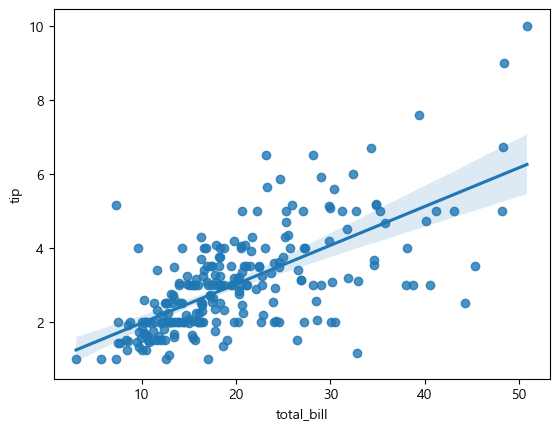

<Figure size 400x300 with 0 Axes>

In [16]:
sns.regplot(data = df , x = 'total_bill' , y = 'tip') # Regression 모델(알고리즘)
plt.figure(figsize = (4,3))

<Axes: xlabel='total_bill', ylabel='tip'>

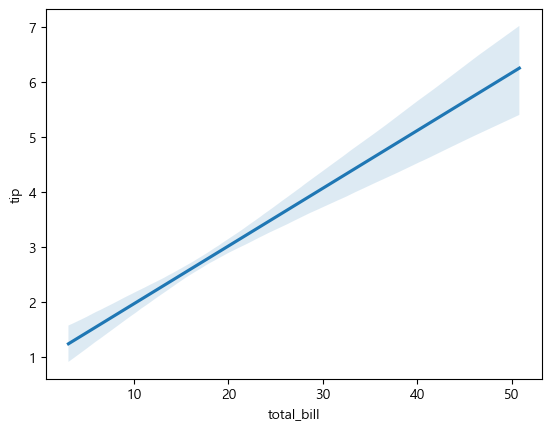

In [17]:
sns.regplot(data = df , x = 'total_bill' , y = 'tip' , scatter = False ) # 상관관계만 파악 

<Axes: xlabel='total_bill', ylabel='tip'>

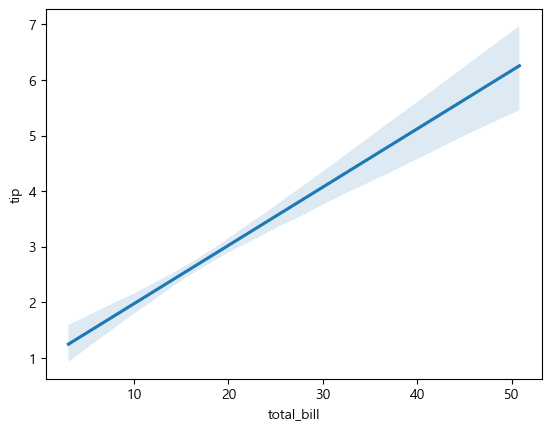

In [18]:
sns.regplot(data = df , x = 'total_bill' , y = 'tip' , scatter = False , ci = 95) # CI : Confidence Level

<Axes: xlabel='total_bill', ylabel='tip'>

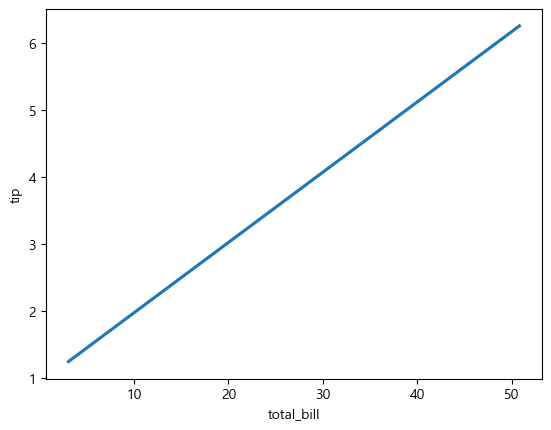

In [19]:
sns.regplot(data = df , x = 'total_bill' , y = 'tip' , scatter = False , ci = False )

In [20]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='size', ylabel='tip'>

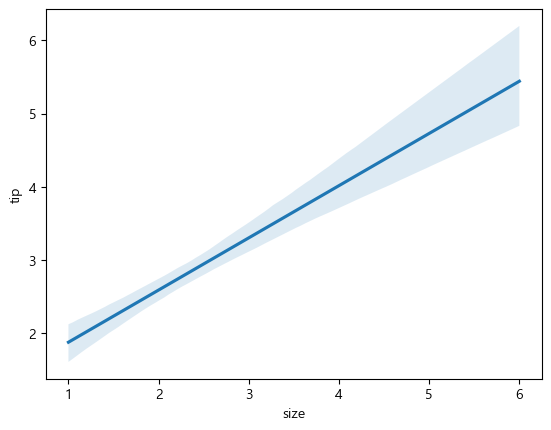

In [21]:
sns.regplot(data = df , x = 'size' , y = 'tip' , ci =95 ,scatter = False)

<Axes: xlabel='size', ylabel='total_bill'>

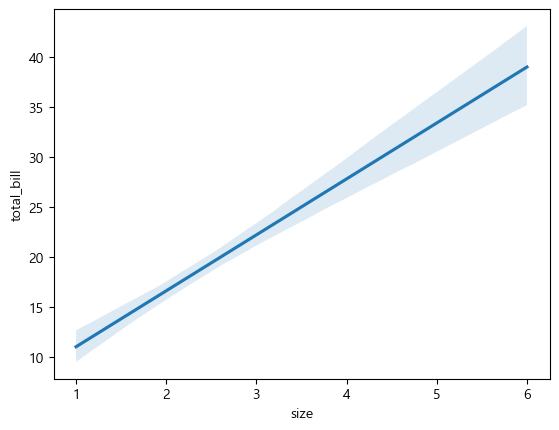

In [22]:
sns.regplot(data = df , x = 'size' , y = 'total_bill' , ci =95 ,scatter = False)

<Axes: xlabel='size', ylabel='tip'>

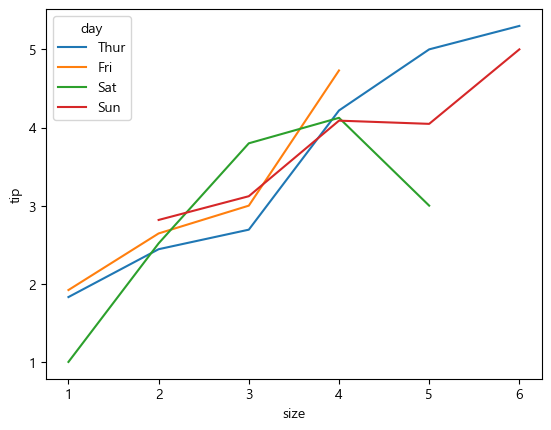

In [23]:
sns.lineplot(data = df , x = 'size' , y = 'tip' , hue = 'day' , errorbar = None) # errorbar = ci

<Axes: xlabel='size', ylabel='tip'>

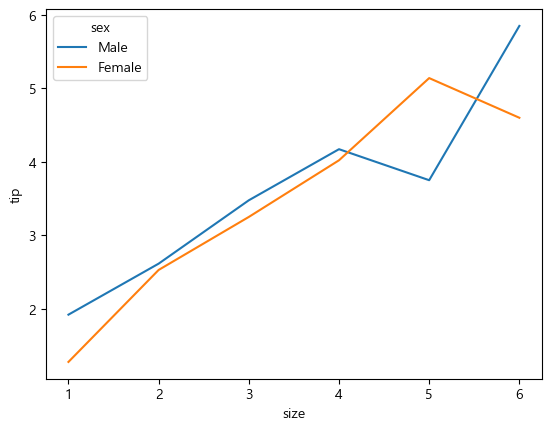

In [24]:
sns.lineplot(data = df , x = 'size' , y = 'tip' , hue = 'sex' , errorbar = None) # errorbar = ci

- 남성이 여성보다 팁을 많이 주는 경향이 있으나 , size가 4~5인 지점에서는 상대적으로 여성이 남성보다 팁을 1이상 준다 . 
- 여성의 팁은 대체적으로 size가 늘어날수록 증가하나 size=5인 지점에서부터 감소한다.

<Axes: xlabel='day', ylabel='total_bill'>

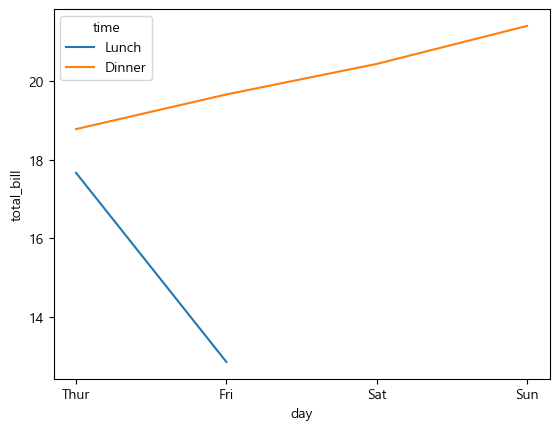

In [25]:
sns.lineplot(x=df['day'],y=df['total_bill'],hue=df['time'],errorbar=None)

- 저녁식사의 총 수입은 요일이 지날수록 우상향한다.
- 점심식사의 총 수입은 요일이 지날수록 우하향하다가, 토,일요일엔 수입이 발생하지 않는다.

In [26]:
# import warnings

# warnings.filterwarnings('ignore')


# 경고 무시 

<Axes: xlabel='size', ylabel='tip'>

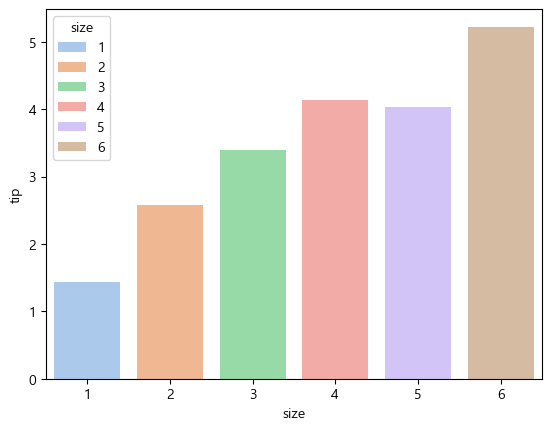

In [27]:
sns.barplot(data = df , x = 'size' , y = 'tip' , hue = 'size' , palette = 'pastel' ,errorbar = None)

<Axes: xlabel='size', ylabel='tip'>

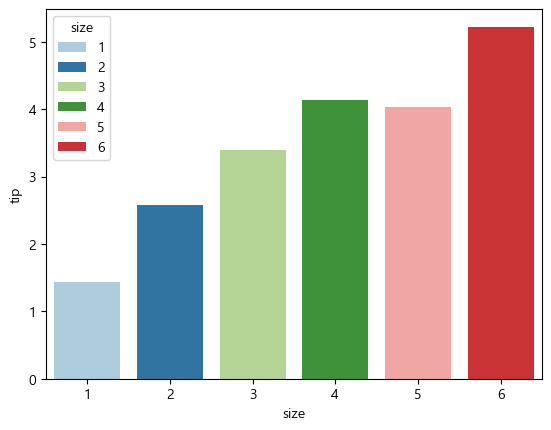

In [28]:
sns.barplot(data = df , x = 'size' , y = 'tip' , hue = 'size' , palette = 'Paired' ,errorbar = None)

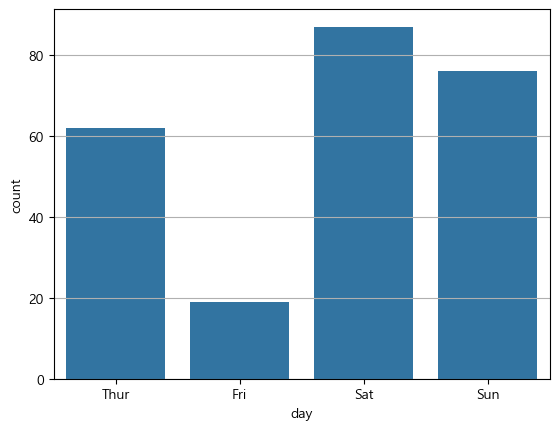

In [29]:
sns.countplot(data = df , x = 'day')
plt.grid(axis = 'y')

<Axes: xlabel='size', ylabel='tip'>

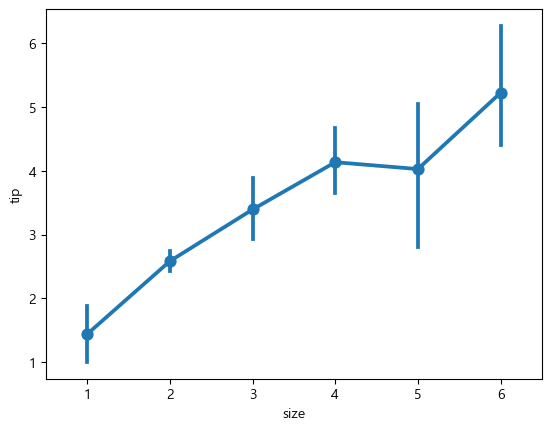

In [30]:
sns.pointplot(data = df , x = 'size' , y = 'tip')

<Axes: xlabel='size', ylabel='tip'>

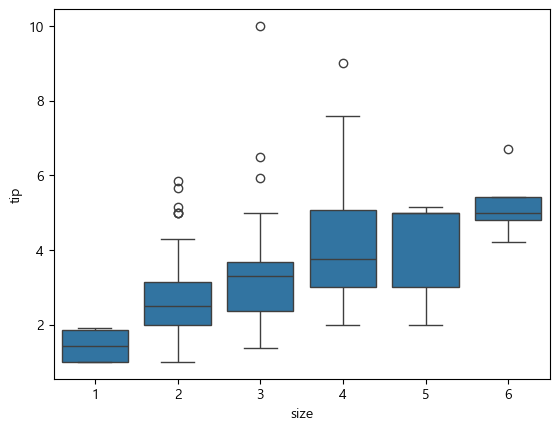

In [31]:
sns.boxplot(data = df , x = 'size' , y = 'tip')

<Axes: xlabel='size', ylabel='tip'>

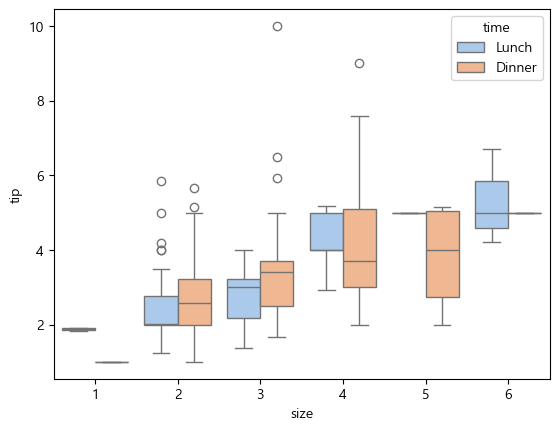

In [32]:
sns.boxplot(data = df , x = 'size' , y = 'tip' , hue = 'time' , palette = 'pastel')

<Axes: xlabel='size', ylabel='tip'>

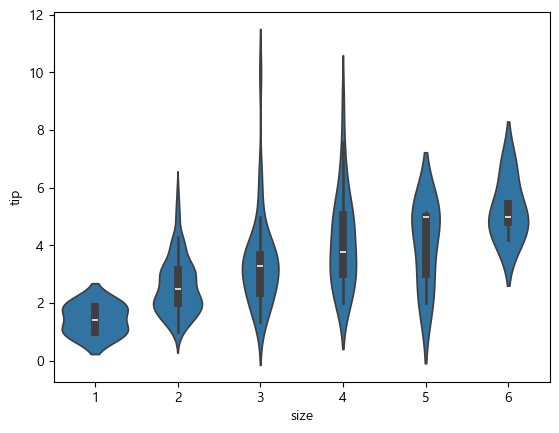

In [33]:
sns.violinplot(data = df , x = 'size' , y = 'tip')

<Axes: xlabel='total_bill', ylabel='Count'>

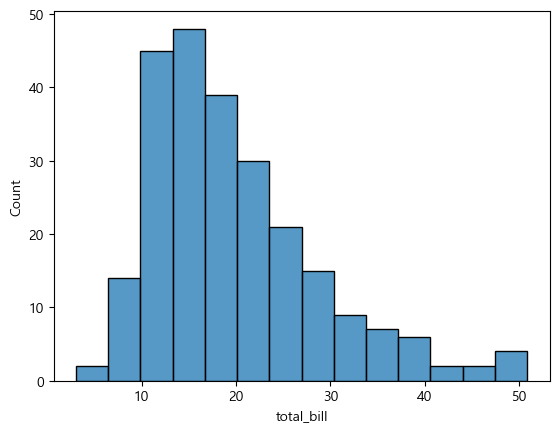

In [34]:
sns.histplot(data = df , x = 'total_bill')

<Axes: xlabel='total_bill', ylabel='Count'>

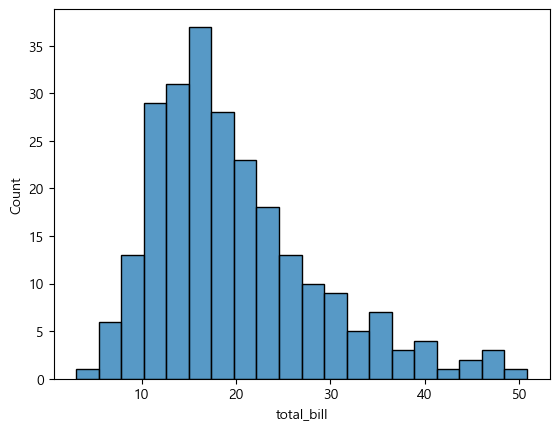

In [35]:
sns.histplot(data = df , x = 'total_bill',bins = 20)

<Axes: xlabel='total_bill', ylabel='Count'>

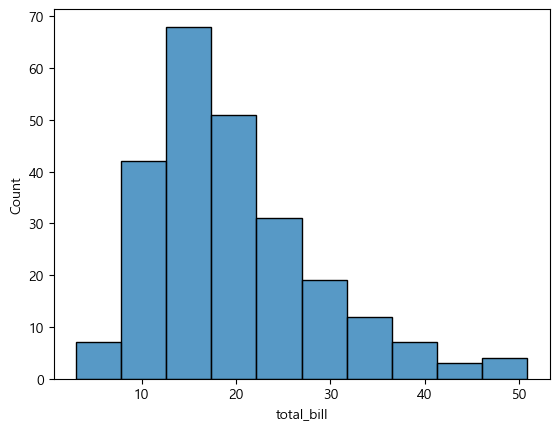

In [36]:
sns.histplot(data = df , x = 'total_bill',bins = 10)

<Axes: xlabel='total_bill', ylabel='Count'>

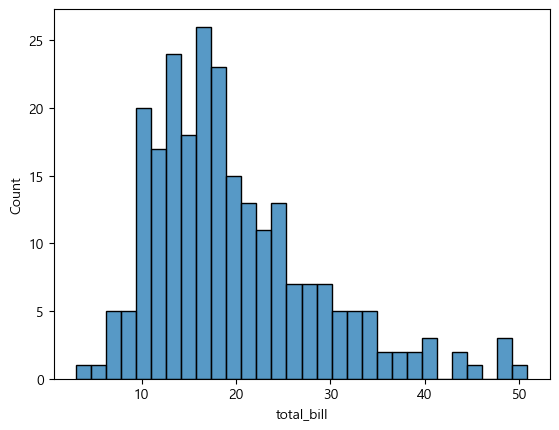

In [37]:
sns.histplot(data = df , x = 'total_bill',bins = 30)

<Axes: xlabel='total_bill', ylabel='Count'>

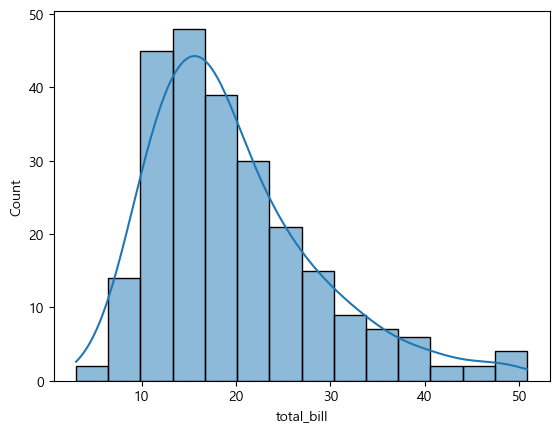

In [38]:
# kde : Kernel Density Estimation

sns.histplot(data = df , x = 'total_bill',kde = True)

<Axes: xlabel='total_bill', ylabel='Density'>

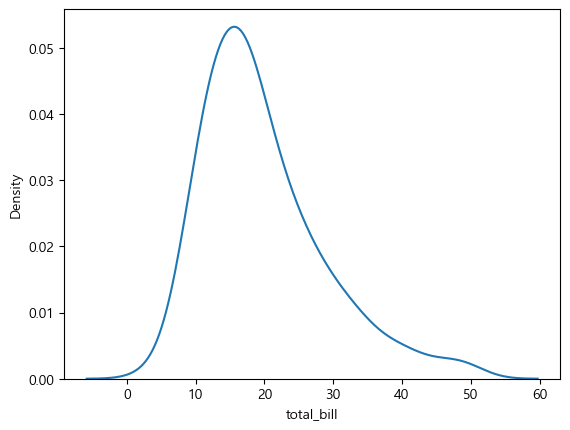

In [39]:
sns.kdeplot(data = df , x = 'total_bill')  # 커널 밀도 함수 

pivot_table 

- 행 , 열 기준으로 재구성해 합계 , 평균 등 집계값을 한눈에 요약하는 기능
- Pandas에서는 pd.pivot_table()로 유사하게 구현
- 데이터를 원하는 기준으로 묶어서 요약표를 만드는 함수

In [40]:
# observed = False : 범주형 데이터를 피벗 테이블로 만들때 , 실제 데이터에 없는 조합까지 표시할지를 결정하는 옵션
# df 데이터프레임에서 day를 행으로 size를 열로 배치하고 , 각 요일과 인원수 조합별로 tip의 평균을 계산하는 피벗팅

pivot_df = df.pivot_table('tip','day','size',observed = False)
pivot_df

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,NaN,NaN
Sat,1.00,2.517547,3.797778,4.123846,3.000000,NaN
Sun,NaN,2.816923,3.120667,4.087778,4.046667,5.0


In [41]:
# 집계함수 aggfunc : 피벗 테이블에서 같은 그룹으로 묶인 값들을 어떻게 계산할지 결정하는 옵션
# mean  : 평균계산 , sum : 합계계산 , count : 개수 계산 , max : 최대값 계산 , min : 최소값 계산,
pivot_df = df.pivot_table('tip','day','size',aggfunc="mean" ,observed = False)
pivot_df

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,NaN,NaN
Sat,1.00,2.517547,3.797778,4.123846,3.000000,NaN
Sun,NaN,2.816923,3.120667,4.087778,4.046667,5.0


In [42]:
pivot_df.fillna(0,inplace = True)
pivot_df

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,0.000000,0.0
Sat,1.00,2.517547,3.797778,4.123846,3.000000,0.0
Sun,0.00,2.816923,3.120667,4.087778,4.046667,5.0


<Axes: xlabel='size', ylabel='day'>

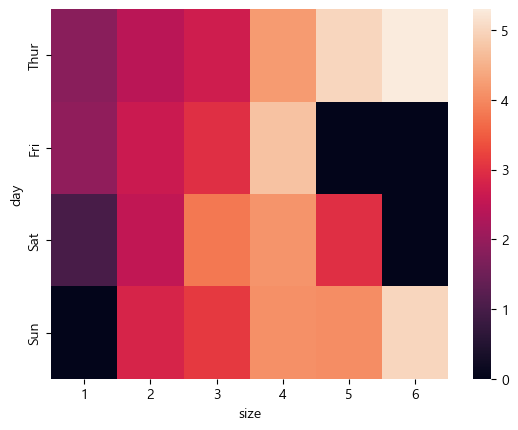

In [43]:
# 가장 강력한 시각 분석 도구 

sns.heatmap(pivot_df)

<Axes: xlabel='size', ylabel='day'>

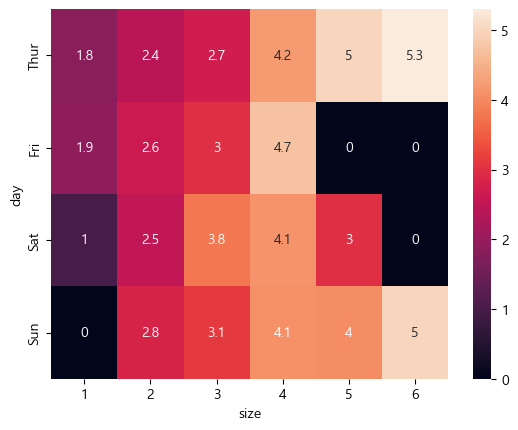

In [44]:
sns.heatmap(pivot_df,annot = True) # annot : 어노테이션

In [45]:
# 연도별 철도 이용자 수 

data = {
    'Month': ['JAN', 'FEB', 'MAR', 'APR', 'MAY'],
    '1958': [340, 318, 362, 348, 363],
    '1959': [360, 342, 406, 396, 420],
    '1960': [417, 391, 419, 461, 472]
}
data

{'Month': ['JAN', 'FEB', 'MAR', 'APR', 'MAY'],
 '1958': [340, 318, 362, 348, 363],
 '1959': [360, 342, 406, 396, 420],
 '1960': [417, 391, 419, 461, 472]}

In [46]:
df = pd.DataFrame(data)
df

,Month,1958,1959,1960
0,JAN,340,360,417
1,FEB,318,342,391
2,MAR,362,406,419
3,APR,348,396,461
4,MAY,363,420,472


In [67]:
pivot_table = df.pivot_table(index="Month" , aggfunc = 'mean')
pivot_table

,1958,1959,1960
Month,,,
APR,348.0,396.0,461.0
FEB,318.0,342.0,391.0
JAN,340.0,360.0,417.0
MAR,362.0,406.0,419.0
MAY,363.0,420.0,472.0


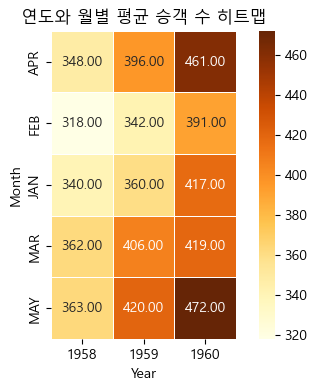

In [74]:
plt.figure(figsize=(6,4))

sns.heatmap(
    pivot_table,
    fmt = '.2f' , 
    annot = True , 
    cmap = 'YlOrBr', 
    square = True,
    linewidths = 0.5 )

plt.title('연도와 월별 평균 승객 수 히트맵')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

- 1960년 5월에 철도 이용자 수가 가장 많다
- 1958년 2월에 철도 이용자 수가 가장 적다
- 철도 이용자 수는 매년 증가했다 .